In [4]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from pathlib import Path
from dask.distributed import Client
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import sys, os

from metpy.calc import dewpoint_from_specific_humidity
from metpy.units import units

import xesmf as xe

In [2]:
client = Client(
    n_workers=24,
    threads_per_worker=1
)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 24
Total threads: 24,Total memory: 95.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42855,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:35159,Total threads: 1
Dashboard: /proxy/37611/status,Memory: 3.96 GiB
Nanny: tcp://127.0.0.1:33141,


In [5]:
date = '2020-01-01'
num_days = '1'

start_year, start_month, start_day = [int(i) for i in date.split('-')]

# Data boundaries
start_date = datetime(start_year, start_month, start_day)
end_date   = datetime(start_year, start_month, start_day + int(num_days))

In [46]:
lat_min=-35
lat_max=-28.5
lon_min=145
lon_max=151.5

In [47]:
def open_files(root_path, preprocess=None, filename_tag=None):
    '''
    Use xarray's open_mfdataset() to open netcdf files, using arguments optimised for
    opening climate datasets quickly and efficiently.

    INPUTS
    root_path: parent directory where netcdf files are located
    preprocess: preprocessing function to pass into open_mfdataset()
    filename_tag: condition for the filename when globbing files

    OUTPUT
    xarray data combining all netcdf files recursively globbed from root_path, where the
    filename contains "filename_tag" and "preprocess" is applied to the data
    '''
    
    if filename_tag:
        files = [f for f in root_path.rglob(f'*{filename_tag}*.nc')]
    else:
        files = [f for f in root_path.rglob('*.nc')]

    return xr.open_mfdataset(
        files,
        preprocess = preprocess,
        concat_dim='time',
        combine='nested',
        data_vars='minimal',
        coords='minimal',
        compat='override',
        parallel=True,
        chunks='auto'
    )

In [48]:
ghi_path_base = Path('/g/data/rv74/satellite-products/arc/der/himawari-ahi/solar/p1s/v1.1/2020/01/')

helio_vars = [
    'surface_global_irradiance',
    'cloud_optical_depth',
    'solar_elevation',
]

# keep just the region and variables during preprocessing
def preprocess(ds):
    return ds.sel(
        latitude=slice(lat_min, lat_max),
        longitude=slice(lon_min, lon_max)
    )[helio_vars].isel(latitude=slice(0, 256), longitude=slice(-256, None))

In [49]:
for day in range(1, 2):
    ghi_path_daily = ghi_path_base / f"{day:02d}"
    # Open the data
    ghi = open_files(ghi_path_daily, preprocess=preprocess)
    
    save_path = Path("/scratch/er8/cd3022/DiT_data/")
    os.makedirs(save_path, exist_ok=True)
    file_name = save_path / f"dit_data_{day}.nc"
    # ghi.to_netcdf(file_name)

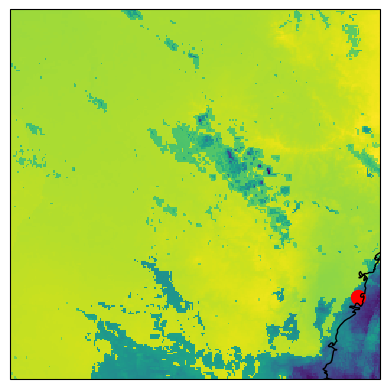

In [50]:
fig, ax = plt.subplots(nrows=1, ncols=1, subplot_kw={'projection': ccrs.PlateCarree()})
syd_coords = (-33.876, 151.211)
ax.pcolormesh(
    ghi.longitude,
    ghi.latitude,
    ghi.isel(time=50).surface_global_irradiance,
    cmap='viridis', shading='auto',
    transform=ccrs.PlateCarree()
)

ax.coastlines()
ax.scatter(syd_coords[1], syd_coords[0], color='red', marker='o', s=100)

# BARRA

In [51]:
# BARRA-R2 Data
files = []
year  = start_date.year
month = start_date.month

# STANDARD VARS
variables_of_interest = [
    # Moisture
    'huss',
    'hus850',
    'hus700',
    'hus500',
    # Wind
    # 'ua850',
    # 'va850',
    # 'wa850',
    # Pressure and geopotential
    'psl',
    # 'zg850',
    # 'zg500',
    # Temperature
    'tas',
    'ta850',
    'ta700',
    'ta500',
    # radiation
    # 'rsds',
]
for var in variables_of_interest:
    file_path = Path(f'/g/data/ob53/BARRA2/output/reanalysis/AUS-11/BOM/ERA5/historical/hres/BARRA-R2/v1/1hr/{var}/latest/')
    var_file = [f for f in file_path.glob(f'*{year}{month:02d}.nc')][0]
    files.append(var_file)

# CONVECTIVE VARS

variables_of_interest = [
    'RH24mean',
    'MUEL',
    'FZL',
    'MULCL'
]
for var in variables_of_interest:
    file_path = Path(f'/g/data/ob53/BARRA2/output/reanalysis/AUST-11/BOM/ERA5/historical/hres/BARRA-R2/v1/1hr/{var}/latest/')
    var_file = [f for f in file_path.glob(f'*{year}{month:02d}.nc')][0]
    files.append(var_file)

# adjust time for UTC
au_start_date = start_date - timedelta(hours=10)
au_end_date = end_date - timedelta(hours=10)
# Keep just time and region 
def preprocess(ds):
    return ds.sel(
        lat=slice(ghi.latitude.min().item(), ghi.latitude.max().item()),
        lon=slice(ghi.longitude.min().item(), ghi.longitude.max().item()),
        time=slice(np.datetime64(au_start_date), np.datetime64(au_end_date))
    )
# Open BARRA Data
bar = xr.open_mfdataset(
    files,
    preprocess = preprocess,
    concat_dim='time',
    combine='nested',
    data_vars='minimal',
    coords='minimal',
    compat='override',
    parallel=True,
    chunks='auto'
)

# When there is 0 CAPE, MUEL is nan.
# To fix this and make sure the model is trained off all environments,
# set MUEL to 0 where there are nan values.
# Other variables (e.g. CIN) are not so easily set to 0
bar['MUEL'] = xr.where(bar['MUEL'].isnull(), 0, bar['MUEL'])


# Calculate dew points for thunderstorm parameters
for pressure in ['850', '700', '500']:
    bar[f'dp{pressure}'] = (
        dewpoint_from_specific_humidity(
            pressure=int(pressure) * units.hPa,
            specific_humidity=bar[f'hus{pressure}'] * units('g/g'),
        )
        .metpy.convert_units('K')   # or 'K' depending on your preference
        .metpy.dequantify()            # removes units → returns plain DataArray
    )

# Convective Parameters from RAW TS Climatology Paper
bar['KI'] = bar['ta850'] - bar['ta500'] + bar['dp850'] - (bar['ta700'] - bar['dp700'])
bar['TCD'] = bar['MUEL'] - bar['MULCL']

In [58]:
# Compute weights once
regridder = xe.Regridder(bar, ghi, method='bilinear')
regridder.to_netcdf('/scratch/er8/cd3022/CPDiT/regridders/barra_to_heliosat.nc')   # reuse across runs

'/scratch/er8/cd3022/CPDiT/regridders/barra_to_heliosat.nc'

TO DO:
- Save per-day or per-month netCDF files (keep sources separate). Chunked by time so you can load individual days efficiently
- A normalisation statistics file (once per dataset). Compute per-channel mean and standard deviation over your training set and store them e.g. channel_0003: {'mean': 0.35, 'std': 0.18}, barra_KI: ...
- A valid timestamp index (once). A simple CSV or parquet file listing every valid sequence start time — i.e. timestamps where a full context_length + forecast_length window exists with no gaps or missing scans

In [ ]:
"Revised Config Structure"
# For CPDiT/configs/train_config.yaml

data:
  context_length: 12
  forecast_length: 6
  target_grid:
    resolution_km: 2.0
    lat_min: -45.0
    lat_max: 0.0
    lon_min: 130.0
    lon_max: 175.0
    patch_size: 128        # pixels, fed to VAE (must be divisible by 8)

  sources:
    himawari_vis:
      paths:
        train: /data/himawari/vis/train/
        val:   /data/himawari/vis/val/
      regrid_weights: /data/weights/himawari_vis_to_target.nc
      normalisation:  /data/stats/himawari_vis_stats.json

    himawari_ir:
      paths:
        train: /data/himawari/ir/train/
        val:   /data/himawari/ir/val/
      regrid_weights: /data/weights/himawari_ir_to_target.nc
      normalisation:  /data/stats/himawari_ir_stats.json

    nwp_access:
      paths:
        train: /data/nwp/access/train/
        val:   /data/nwp/access/val/
      regrid_weights: /data/weights/nwp_to_target.nc
      normalisation:  /data/stats/nwp_stats.json
      temporal_interp: nearest    # how to align NWP to satellite timestamps

  valid_timestamps:
    train: /data/index/train_index.parquet
    val:   /data/index/val_index.parquet

  num_workers: 4
